# Model training: data science salary prediction

Trains the model served by `api/model.py` (`models/decision_tree_model.pkl`).

* **Input:** `data/processed/processed_salaries.csv`, the encoded output of `preprocessing.ipynb` (see *Input Encoding* in the README)
* **Target:** `salary_in_usd`
* **Model:** `DecisionTreeRegressor`, with depth chosen by 5-fold cross-validation on the training split only; the test split is scored once at the end

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.tree import DecisionTreeRegressor

SEED = 42
FEATURES = ["work_year", "experience_level", "job_title", "remote_ratio", "company_location", "company_size"]

df = pd.read_csv("../data/processed/processed_salaries.csv")
X, y = df[FEATURES], df["salary_in_usd"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print(f"{len(df)} rows -> train {len(X_train)}, test {len(X_test)}")
y.describe().round(0)

607 rows -> train 485, test 122


count       607.0
mean     110031.0
std       62146.0
min        2859.0
25%       62726.0
50%      101570.0
75%      150000.0
max      280911.0
Name: salary_in_usd, dtype: float64

## Choose tree depth with cross-validation (training split only)

In [2]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
rows = []
for d in depths:
    scores = cross_val_score(DecisionTreeRegressor(max_depth=d, random_state=SEED), X_train, y_train, cv=cv, scoring="r2")
    rows.append({"max_depth": str(d), "cv_r2_mean": scores.mean(), "cv_r2_std": scores.std()})
cv_results = pd.DataFrame(rows)
# One-standard-error rule: the shallowest tree whose CV score is within one
# standard error of the best. Scores within noise favour the simpler model.
best = cv_results["cv_r2_mean"].idxmax()
threshold = cv_results.loc[best, "cv_r2_mean"] - cv_results.loc[best, "cv_r2_std"] / np.sqrt(cv.get_n_splits())
best_depth = next(d for d, m in zip(depths, cv_results["cv_r2_mean"]) if m >= threshold)
print(f"best CV R2 {cv_results.loc[best, 'cv_r2_mean']:.3f}; 1-SE threshold {threshold:.3f} -> max_depth = {best_depth}")
cv_results.round(3)

best CV R2 0.389; 1-SE threshold 0.362 -> max_depth = 4


,max_depth,cv_r2_mean,cv_r2_std
0,1,0.245,0.039
1,2,0.346,0.062
2,3,0.347,0.064
3,4,0.389,0.051
4,5,0.389,0.060
5,6,0.289,0.099
6,8,0.239,0.100
7,10,0.159,0.082
8,None,0.158,0.101


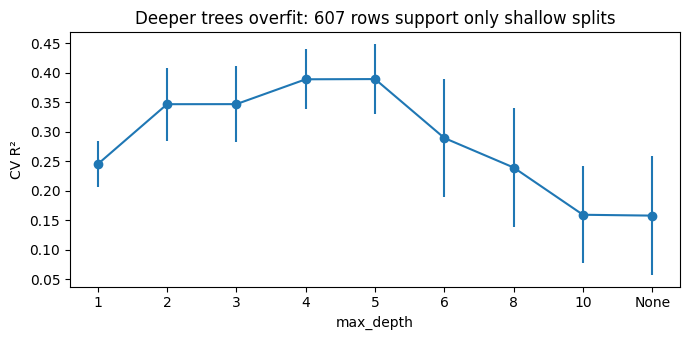

In [3]:
ax = cv_results.plot(x="max_depth", y="cv_r2_mean", yerr="cv_r2_std", marker="o", legend=False, figsize=(7, 3.5))
ax.set_ylabel("CV R²"); ax.set_title("Deeper trees overfit: 607 rows support only shallow splits")
plt.tight_layout()

## Final evaluation on the held-out test split (once), against baselines

In [4]:
candidates = {
    "Mean baseline": DummyRegressor(strategy="mean"),
    f"Decision tree (max_depth={best_depth})": DecisionTreeRegressor(max_depth=best_depth, random_state=SEED),
    "Decision tree (unconstrained)": DecisionTreeRegressor(random_state=SEED),
    "Random forest (reference)": RandomForestRegressor(n_estimators=300, max_depth=best_depth, random_state=SEED),
}
results = []
for name, m in candidates.items():
    m.fit(X_train, y_train)
    results.append({"model": name,
                    "train_r2": r2_score(y_train, m.predict(X_train)),
                    "test_r2": r2_score(y_test, m.predict(X_test)),
                    "test_mae_usd": mean_absolute_error(y_test, m.predict(X_test))})
pd.DataFrame(results).round({"train_r2": 3, "test_r2": 3, "test_mae_usd": 0})

,model,train_r2,test_r2,test_mae_usd
0,Mean baseline,0.000,-0.018,45549.0
1,Decision tree (max_depth=4),0.493,0.380,34616.0
2,Decision tree (unconstrained),0.763,0.082,39998.0
3,Random forest (reference),0.516,0.413,33643.0


The unconstrained tree memorises the training data (train R² 0.76, test R² 0.08); the depth-limited tree generalises. A random forest scores slightly higher, but on 6 coarse categorical features the gain is small, so the API keeps the single tree: it is interpretable and fast, and ships as one small file.

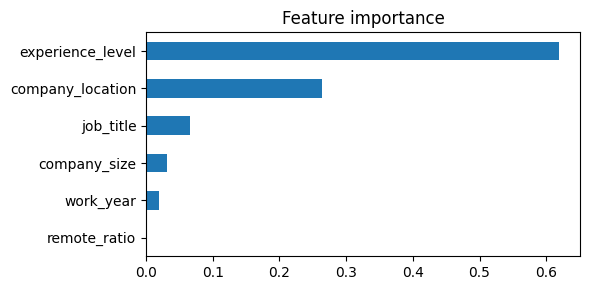

In [5]:
model = candidates[f"Decision tree (max_depth={best_depth})"]
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
importances.plot.barh(figsize=(6, 3), title="Feature importance"); plt.tight_layout()

## Save the model for the API

In [6]:
joblib.dump(model, "../models/decision_tree_model.pkl")
reloaded = joblib.load("../models/decision_tree_model.pkl")
assert list(reloaded.feature_names_in_) == FEATURES
print("saved:", reloaded)

saved: DecisionTreeRegressor(max_depth=4, random_state=42)
